In [ ]:
# MODEL 1: EfficientNetB2 (recommended for leaf-disease texture)
# ============================================================

!pip -q install scikit-learn

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB2
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

In [ ]:
# ✅ CHANGE ONLY THESE
TRAIN_DIR = "/content/drive/MyDrive/Capstone Dataset/Guava_Leaf_Dieases/Train"
TEST_DIR  = "/content/drive/MyDrive/Capstone Dataset/Guava_Leaf_Dieases/Test"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
EPOCHS_HEAD = 5
EPOCHS_FINETUNE = 25
LR_HEAD = 1e-3
LR_FINETUNE = 1e-5

In [ ]:
# 4) Load Dataset (Already split: Train/Test)
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="int", shuffle=True
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="int", shuffle=False
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="int", shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)

if val_ds.class_names != class_names:
    raise ValueError(
        "Class mismatch between Train and Test folders.\n"
        f"Train: {class_names}\nTest : {val_ds.class_names}"
    )

Found 4600 files belonging to 5 classes.
Found 1150 files belonging to 5 classes.
Found 1150 files belonging to 5 classes.
Classes: ['Anthracnose', 'Canker', 'Dot', 'Healthy', 'Rust']


In [ ]:
# 5) Data Pipeline Optimization
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000, seed=SEED).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

In [ ]:
# 6) Data Augmentation
data_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.1),
])

In [ ]:
# 7) Build Pretrained Model (Base + Custom Head)
base = EfficientNetB2(include_top=False, weights="imagenet", input_shape=IMG_SIZE + (3,))
base.trainable = False

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = data_aug(inputs)
x = preprocess_input(x)
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.30)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)
model = models.Model(inputs, outputs)

31790344/31790344 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# 8) Train Head (Frozen base)
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", patience=2, factor=0.5),
]

model.compile(
    optimizer=tf.keras.optimizers.Adam(LR_HEAD),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
h1 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_HEAD, callbacks=callbacks)

Epoch 1/5
144/144 ━━━━━━━━━━━━━━━━━━━━ 734s 1s/step - accuracy: 0.4722 - loss: 1.2999 - val_accuracy: 0.6400 - val_loss: 0.9728 - learning_rate: 0.0010
Epoch 2/5
144/144 ━━━━━━━━━━━━━━━━━━━━ 21s 145ms/step - accuracy: 0.7174 - loss: 0.8327 - val_accuracy: 0.6652 - val_loss: 0.9104 - learning_rate: 0.0010
Epoch 3/5
144/144 ━━━━━━━━━━━━━━━━━━━━ 20s 140ms/step - accuracy: 0.7594 - loss: 0.7146 - val_accuracy: 0.6652 - val_loss: 0.9097 - learning_rate: 0.0010
Epoch 4/5
144/144 ━━━━━━━━━━━━━━━━━━━━ 19s 136ms/step - accuracy: 0.7578 - loss: 0.6849 - val_accuracy: 0.6739 - val_loss: 0.8868 - learning_rate: 0.0010
Epoch 5/5
144/144 ━━━━━━━━━━━━━━━━━━━━ 19s 135ms/step - accuracy: 0.7818 - loss: 0.6396 - val_accuracy: 0.6800 - val_loss: 0.8604 - learning_rate: 0.0010


In [ ]:
# 9) Fine-tuning (Unfreeze last layers)
base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(LR_FINETUNE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
h2 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_FINETUNE, callbacks=callbacks)

Epoch 1/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 44s 185ms/step - accuracy: 0.7058 - loss: 0.8029 - val_accuracy: 0.6826 - val_loss: 0.8760 - learning_rate: 1.0000e-05
Epoch 2/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 23s 163ms/step - accuracy: 0.7797 - loss: 0.6210 - val_accuracy: 0.6939 - val_loss: 0.8846 - learning_rate: 1.0000e-05
Epoch 3/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 23s 159ms/step - accuracy: 0.7984 - loss: 0.5800 - val_accuracy: 0.7017 - val_loss: 0.8662 - learning_rate: 1.0000e-05
Epoch 4/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 23s 156ms/step - accuracy: 0.8152 - loss: 0.5380 - val_accuracy: 0.7157 - val_loss: 0.8535 - learning_rate: 1.0000e-05
Epoch 5/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 23s 157ms/step - accuracy: 0.8280 - loss: 0.5194 - val_accuracy: 0.7096 - val_loss: 0.8434 - learning_rate: 1.0000e-05
Epoch 6/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 23s 159ms/step - accuracy: 0.8371 - loss: 0.4744 - val_accuracy: 0.7087 - val_loss: 0.8480 - learning_rate: 1.0000e-05
Epoch 7/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 23s 15

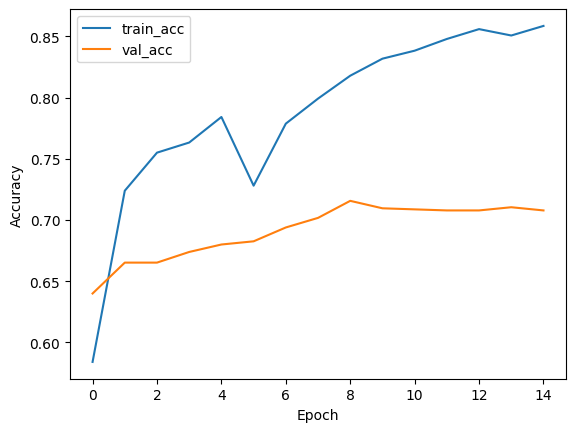

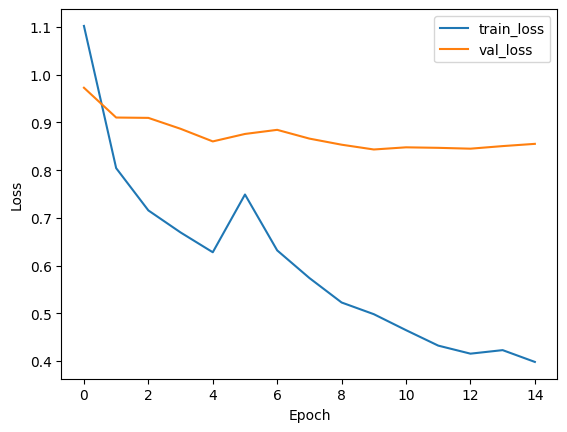

In [ ]:
# 10) Plot Training Curves (Accuracy/Loss)
def plot_curves(h1, h2):
    acc = h1.history["accuracy"] + h2.history["accuracy"]
    val_acc = h1.history["val_accuracy"] + h2.history["val_accuracy"]
    loss = h1.history["loss"] + h2.history["loss"]
    val_loss = h1.history["val_loss"] + h2.history["val_loss"]

    plt.figure()
    plt.plot(acc, label="train_acc")
    plt.plot(val_acc, label="val_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(loss, label="train_loss")
    plt.plot(val_loss, label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

plot_curves(h1, h2)

In [ ]:
# 11) Evaluate on Test Set
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")


Test Accuracy: 0.7096 | Test Loss: 0.8434


In [ ]:
# 12) Predictions
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)
y_prob = model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

In [ ]:
# 13) Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))


Classification Report:
              precision    recall  f1-score   support

 Anthracnose     0.6486    0.8826    0.7477       230
      Canker     0.8638    0.8000    0.8307       230
         Dot     0.5217    0.4174    0.4638       230
     Healthy     0.6823    0.8217    0.7456       230
        Rust     0.8834    0.6261    0.7328       230

    accuracy                         0.7096      1150
   macro avg     0.7200    0.7096    0.7041      1150
weighted avg     0.7200    0.7096    0.7041      1150



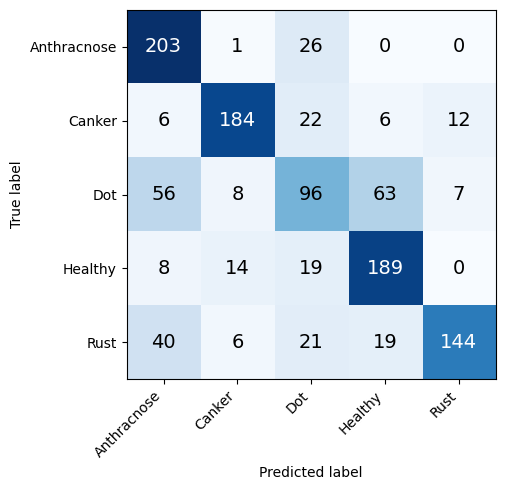

In [ ]:
# 14) Confusion Matrix (blue style like your sample, NO colorbar)
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(7, 5))
ax.imshow(cm, cmap=plt.cm.Blues)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black", fontsize=14)
ax.grid(False)
plt.tight_layout()
plt.show()

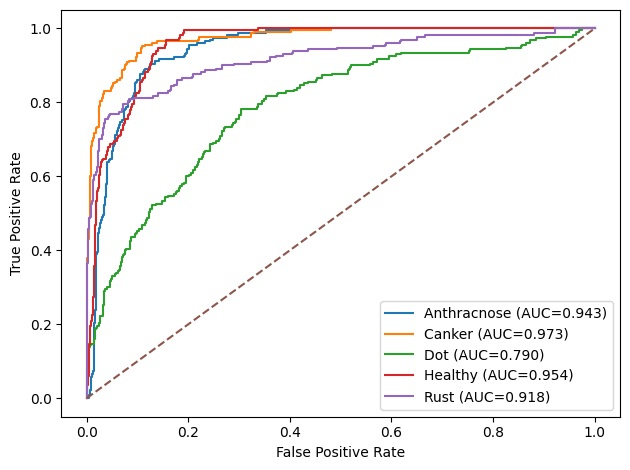

In [ ]:
# 15) ROC Curve (One-vs-Rest)
y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))
plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 17) Save Model
import os
os.makedirs("/content/drive/MyDrive/Capstone Models", exist_ok=True)

model.save("/content/drive/MyDrive/Capstone Models/EfficientNetB2_leaf.keras")
print("Model saved successfully.")

Model saved successfully.
